## Разведочный анализ данных

In [1]:
import os
import sys
from pathlib import Path

# Проверяем, запускался ли уже этот блок
if "IS_ROOT_SET" not in globals():
    project_root = Path.cwd().parent.parent
    os.chdir(project_root)

    if str(project_root) not in sys.path:
        sys.path.insert(0, str(project_root))

    # Создаем флаг-индикатор
    IS_ROOT_SET = True
    print("Корневая директория инициализирована.")
else:
    print("Инициализация уже была выполнена ранее.")


Корневая директория инициализирована.


In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
data = pd.read_parquet("lab5/data/processed/processed_sepsis_data.parquet")

1. Оценка дисбаланса классов

/tmp/ipykernel_4132/2620406238.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="SepsisLabel", data=data, palette="viridis")


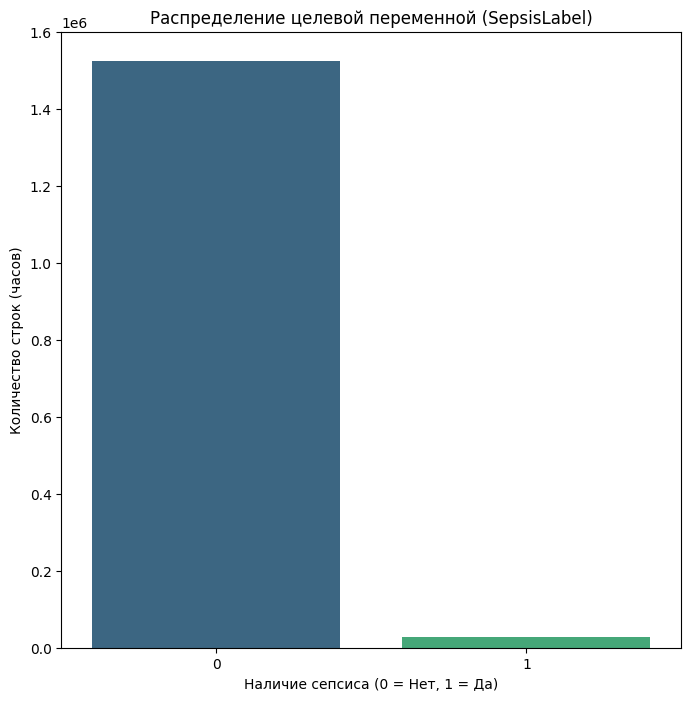

SepsisLabel
0    98.201532
1     1.798468
Name: proportion, dtype: float64


In [4]:
plt.figure(figsize=(8, 8))

sns.countplot(x="SepsisLabel", data=data, palette="viridis")
plt.title("Распределение целевой переменной (SepsisLabel)")
plt.xlabel("Наличие сепсиса (0 = Нет, 1 = Да)")
plt.ylabel("Количество строк (часов)")
plt.show()

print(data["SepsisLabel"].value_counts(normalize=True) * 100)

2. Исследуем пульс пациентов с сепсисом

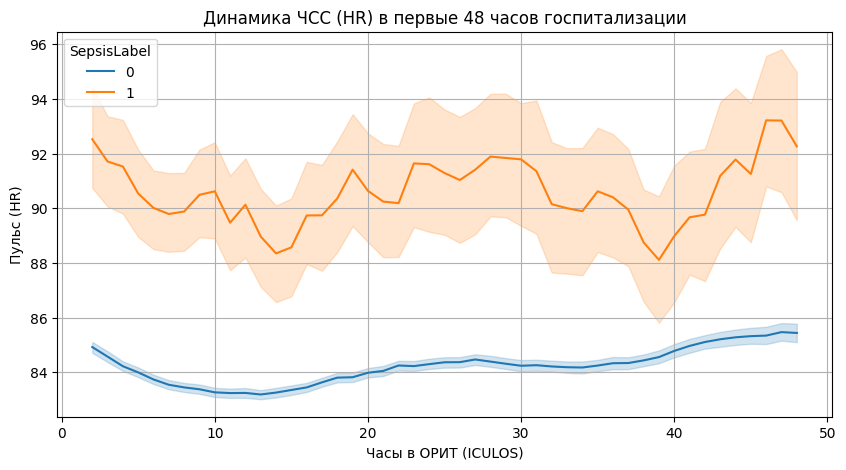

In [5]:
plt.figure(figsize=(10, 5))

sns.lineplot(
    x="ICULOS",
    y="HR",
    hue="SepsisLabel",
    data=data[data["ICULOS"] <= 48],
    errorbar="ci",
)
plt.title("Динамика ЧСС (HR) в первые 48 часов госпитализации")
plt.xlabel("Часы в ОРИТ (ICULOS)")
plt.ylabel("Пульс (HR)")
plt.grid(True)
plt.show()


3. Исследоваие Engeeniring features

/tmp/ipykernel_4132/3638474781.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


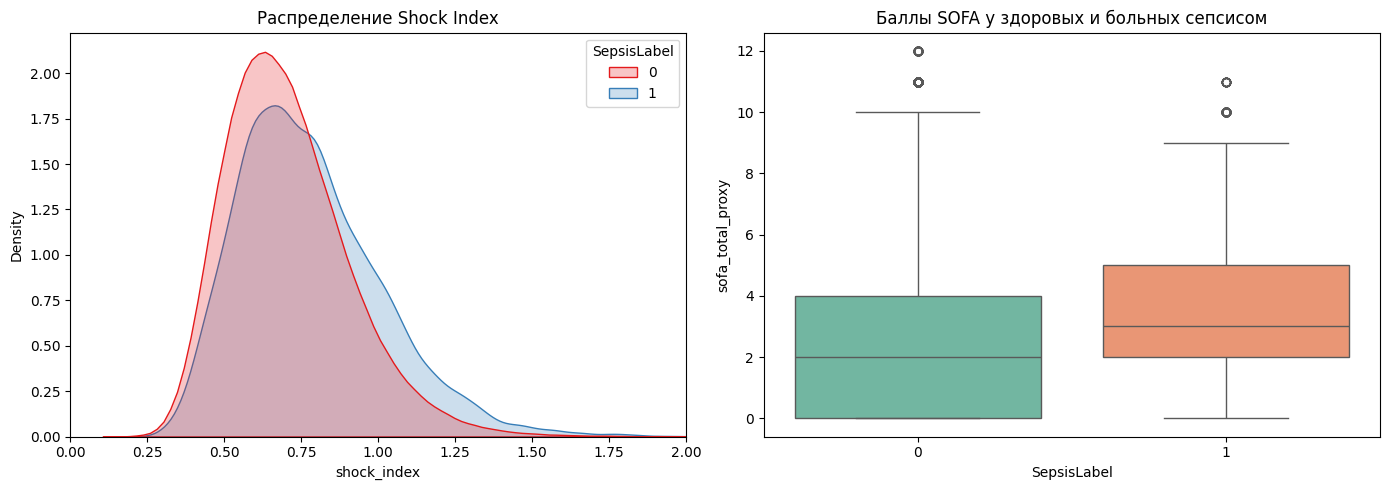

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))


sns.kdeplot(
    data=data,
    x="shock_index",
    hue="SepsisLabel",
    fill=True,
    common_norm=False,
    ax=axes[0],
    palette="Set1",
)
axes[0].set_title("Распределение Shock Index")
axes[0].set_xlim(0, 2)

sns.boxplot(
    data=data, x="SepsisLabel", y="sofa_total_proxy", ax=axes[1], palette="Set2"
)
axes[1].set_title("Баллы SOFA у здоровых и больных сепсисом")

plt.tight_layout()
plt.show()


4. Корреляционная матрица

In [7]:
LAB_FEATURES = [
    "BaseExcess",
    "HCO3",
    "FiO2",
    "pH",
    "PaCO2",
    "SaO2",
    "AST",
    "BUN",
    "Alkalinephos",
    "Calcium",
    "Chloride",
    "Creatinine",
    "Glucose",
    "Lactate",
    "Magnesium",
    "Phosphate",
    "Potassium",
    "WBC",
    "Hct",
    "Hgb",
    "PTT",
    "Fibrinogen",
    "Platelets",
]
VITAL_FEATURES = ["HR", "O2Sat", "Temp", "SBP", "MAP", "DBP", "Resp"]
DEMO_FEATURES = ["Age", "Gender", "Unit1", "Unit2", "HospAdmTime"]

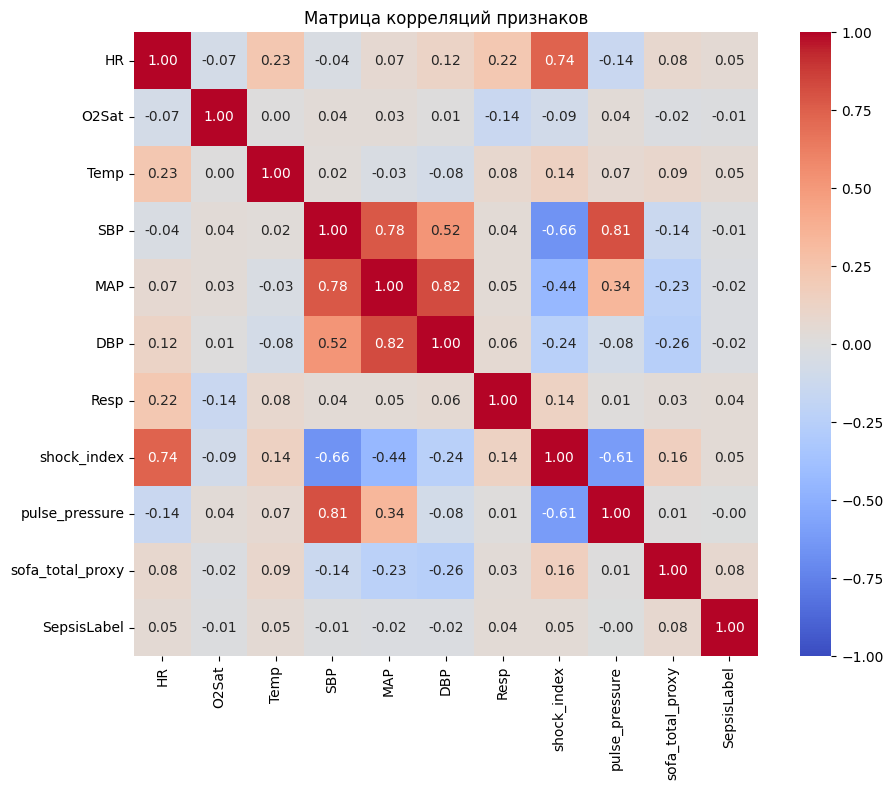

In [8]:
plt.figure(figsize=(10, 8))
features_to_corr = VITAL_FEATURES + [
    "shock_index",
    "pulse_pressure",
    "sofa_total_proxy",
    "SepsisLabel",
]
corr_matrix = data[features_to_corr].corr()

sns.heatmap(
    corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1, square=True
)
plt.title("Матрица корреляций признаков")
plt.tight_layout()
plt.show()


6. Корелляция лабораторных анализов

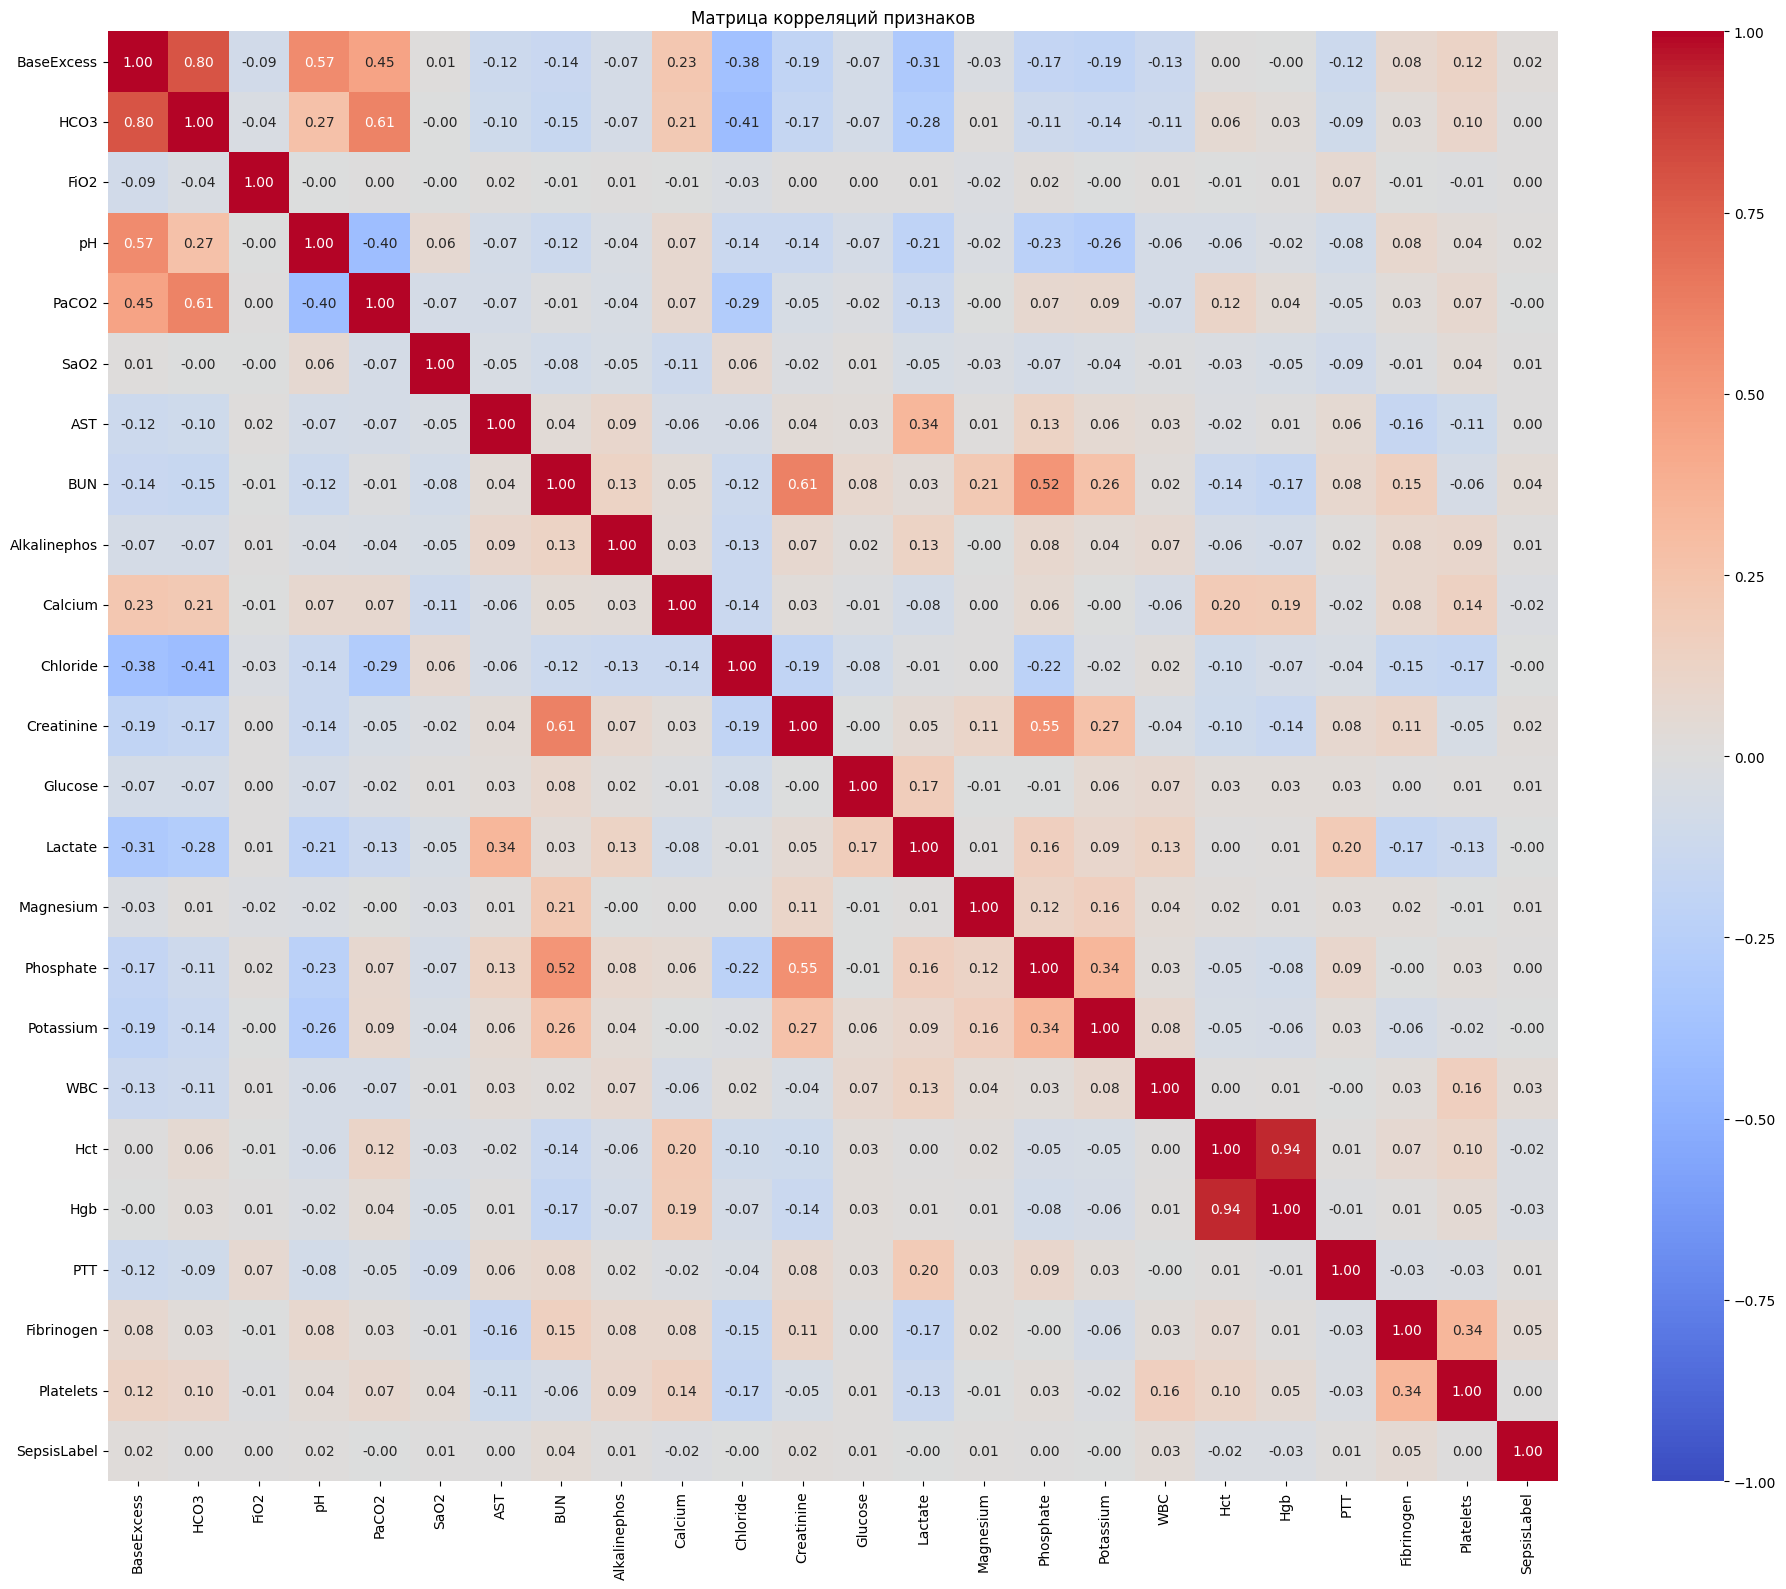

In [9]:
plt.figure(figsize=(20, 16))
corr_matrix = data[LAB_FEATURES + ["SepsisLabel"]].corr()

sns.heatmap(
    corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1, square=True
)
plt.title("Матрица корреляций признаков")
plt.tight_layout()
plt.show()


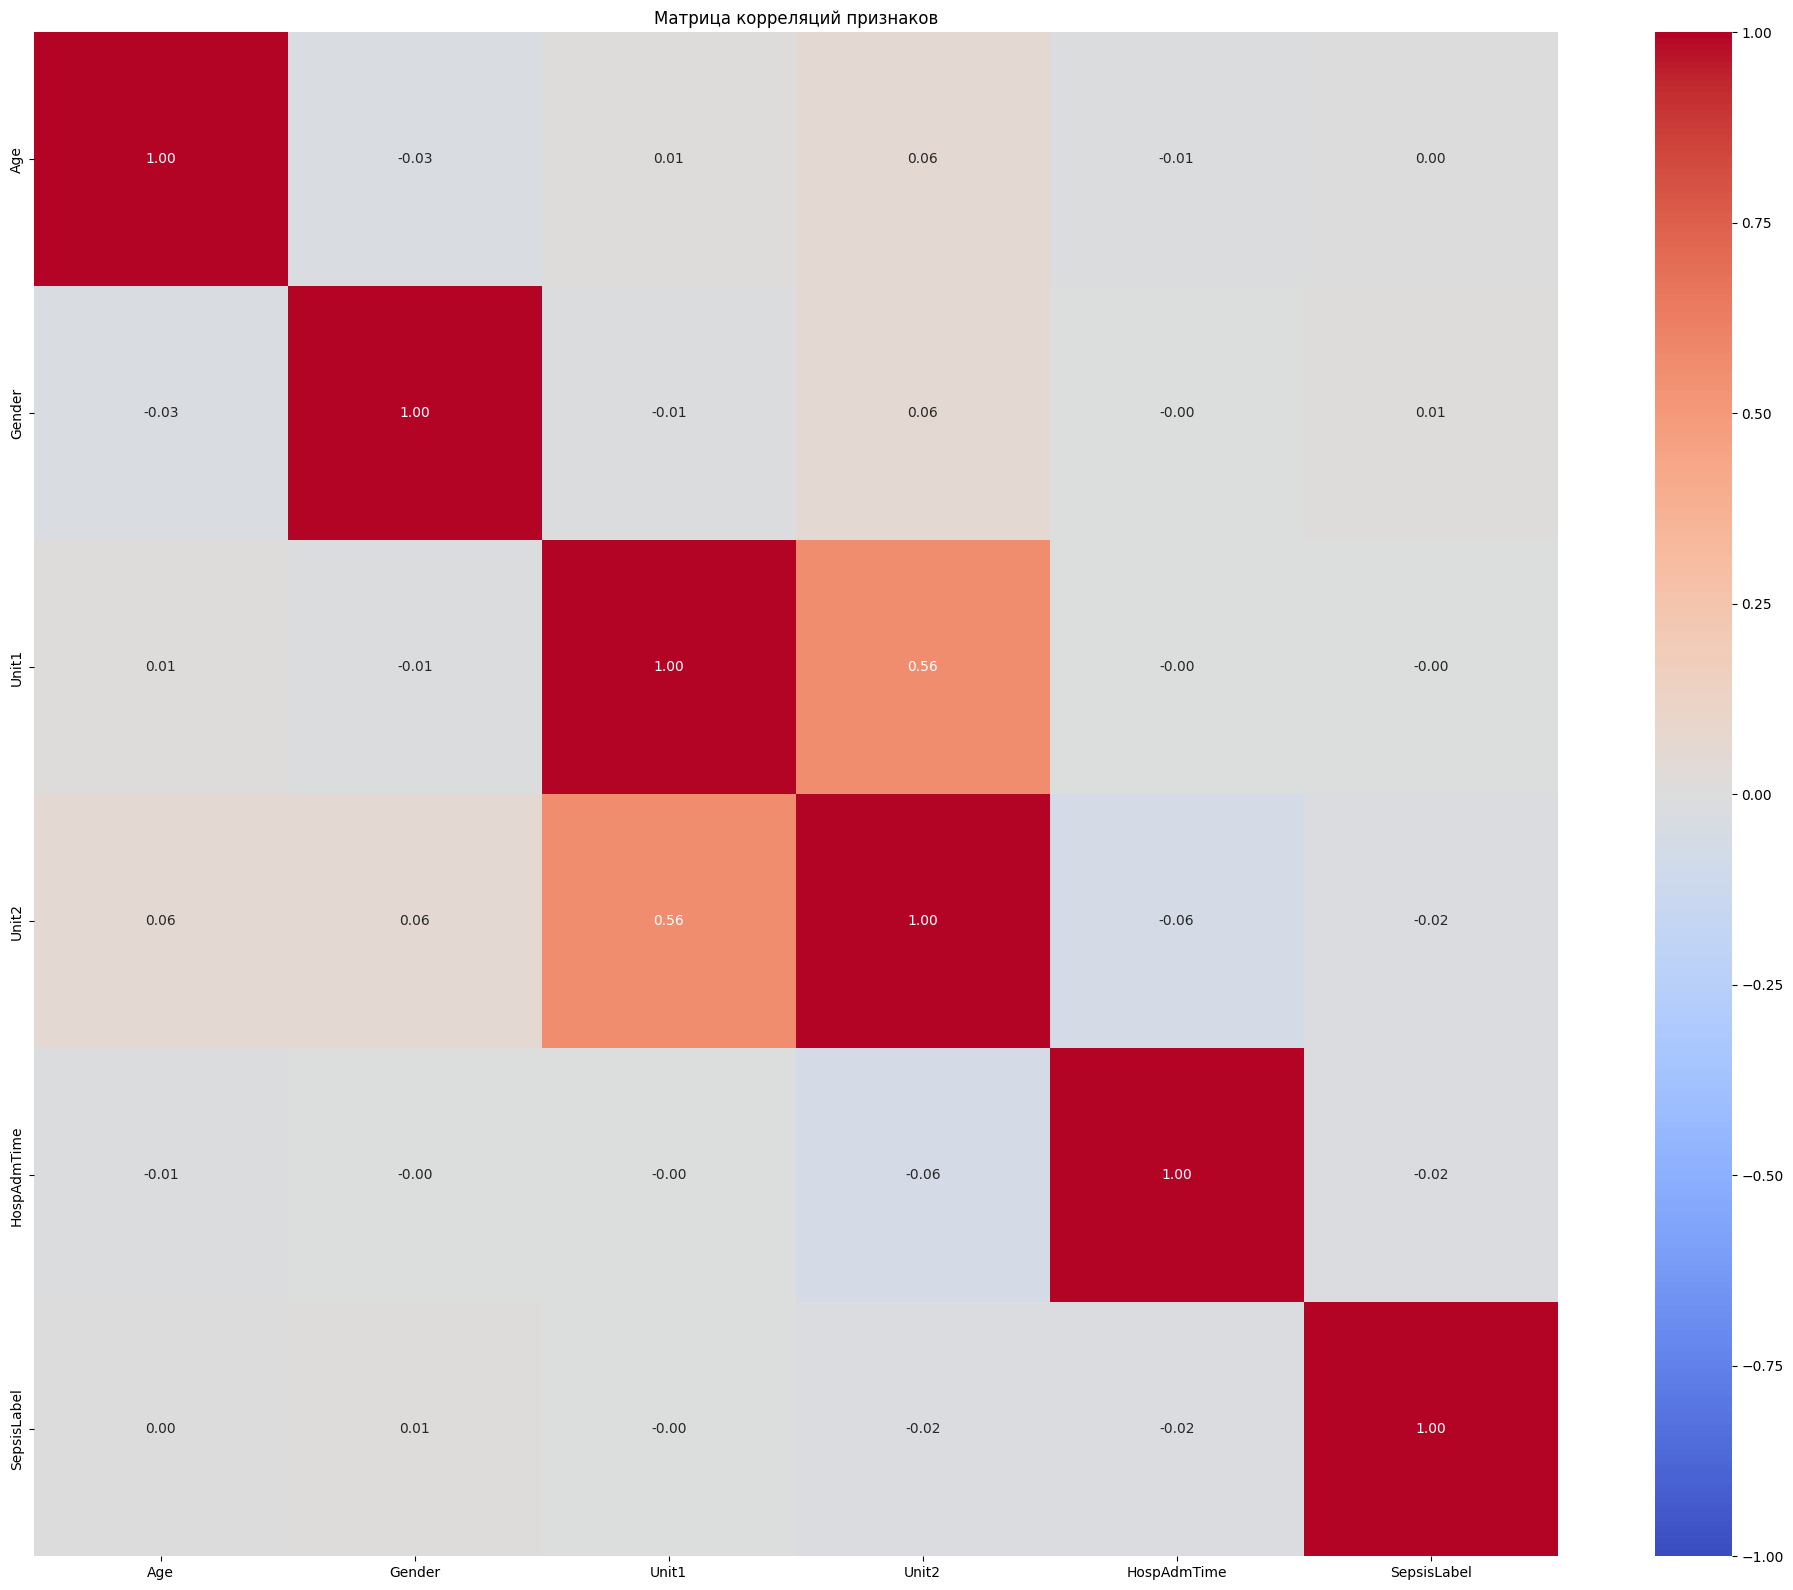

In [10]:
plt.figure(figsize=(20, 16))
corr_matrix = data[DEMO_FEATURES + ["SepsisLabel"]].corr()

sns.heatmap(
    corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1, square=True
)
plt.title("Матрица корреляций признаков")
plt.tight_layout()
plt.show()


Тренды и скользящие окна

In [11]:
KEY_TRENDS = VITAL_FEATURES + ["Lactate", "WBC", "Creatinine", "Platelets"]

ROLLING_BASE = [
    "HR",  #
    "Resp",
    "Lactate",
    "MAP",
    "O2Sat",
    "Temp",
    "SBP",
    "Glucose",
]

HOURS = [1, 3]

ENGINEERED_VITAL_LIST = [f"{f}_mean_6h" for f in ROLLING_BASE] + [
    f"{f}_std_6h" for f in ROLLING_BASE
]
ENGINEERED_TRENDS_LIST = [f"{f}_diff_{h}h" for f in KEY_TRENDS for h in HOURS]

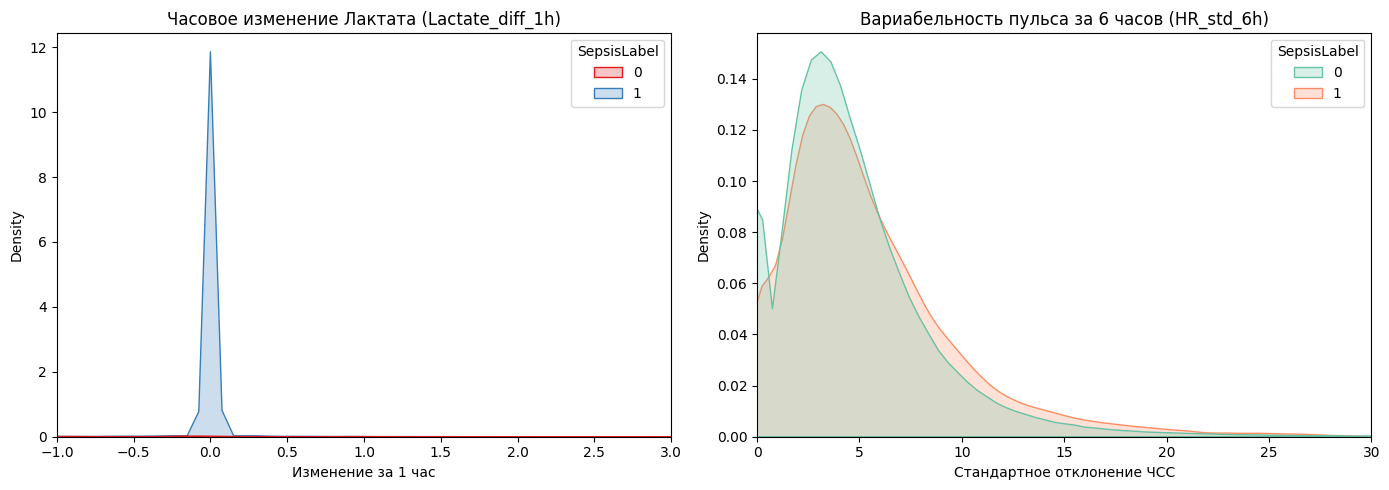

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.kdeplot(
    data=data,
    x="Lactate_diff_1h",
    hue="SepsisLabel",
    fill=True,
    common_norm=False,
    ax=axes[0],
    palette="Set1",
)
axes[0].set_title("Часовое изменение Лактата (Lactate_diff_1h)")
axes[0].set_xlim(-1, 3)
axes[0].set_xlabel("Изменение за 1 час")


sns.kdeplot(
    data=data,
    x="HR_std_6h",
    hue="SepsisLabel",
    fill=True,
    common_norm=False,
    ax=axes[1],
    palette="Set2",
)
axes[1].set_title("Вариабельность пульса за 6 часов (HR_std_6h)")
axes[1].set_xlim(0, 30)
axes[1].set_xlabel("Стандартное отклонение ЧСС")

plt.tight_layout()
plt.show()


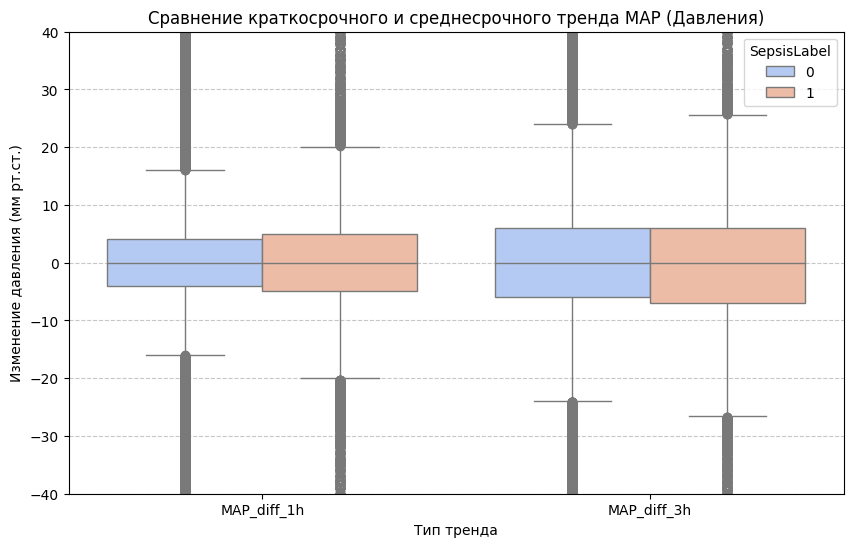

In [13]:
map_trends = data.melt(
    id_vars=["SepsisLabel"],
    value_vars=["MAP_diff_1h", "MAP_diff_3h"],
    var_name="Trend_Type",
    value_name="Value",
)

plt.figure(figsize=(10, 6))
sns.boxplot(
    data=map_trends, x="Trend_Type", y="Value", hue="SepsisLabel", palette="coolwarm"
)
plt.title("Сравнение краткосрочного и среднесрочного тренда MAP (Давления)")
plt.ylim(-40, 40)
plt.xlabel("Тип тренда")
plt.ylabel("Изменение давления (мм рт.ст.)")
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.show()


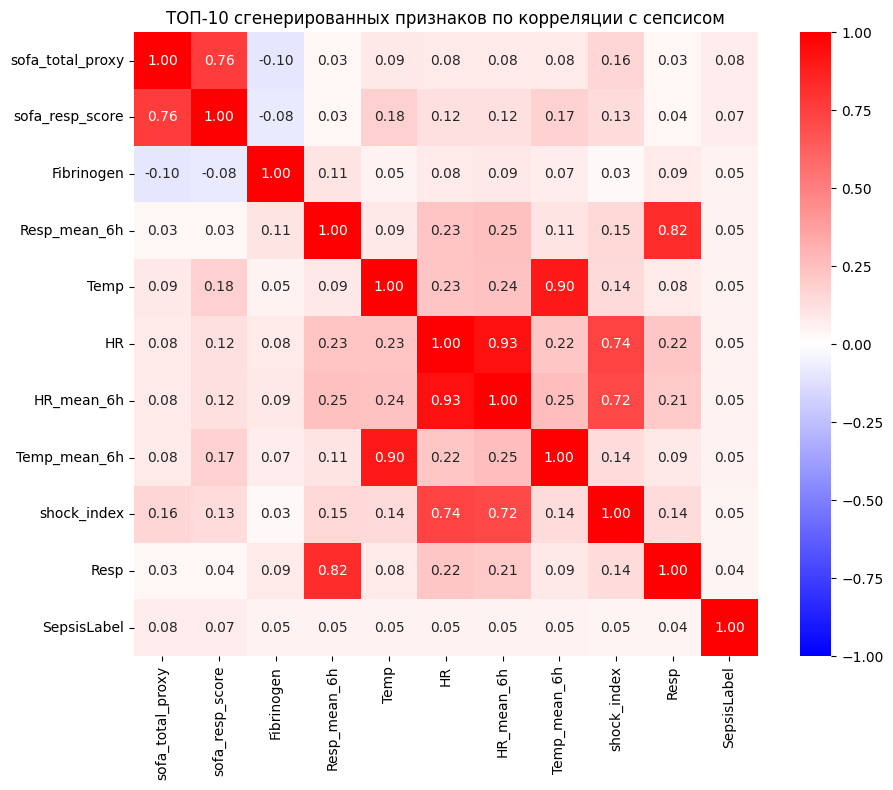

In [14]:
ALL_FEATURES = VITAL_FEATURES + LAB_FEATURES + DEMO_FEATURES
ENGINEERED_FEATURES = [
    "sofa_cv_score",
    "sofa_resp_score",
    "sofa_renal_score",
    "sofa_coag_score",
    "sofa_total_proxy",
    "shock_index",
    "pulse_pressure",
]
FEATURES_FOR_MODEL = (
    ALL_FEATURES + ENGINEERED_VITAL_LIST + ENGINEERED_TRENDS_LIST + ENGINEERED_FEATURES
)

all_engineered_features = FEATURES_FOR_MODEL
correlations = data[all_engineered_features + ["SepsisLabel"]].corr()["SepsisLabel"]


top_features = correlations.abs().sort_values(ascending=False).iloc[1:11].index.tolist()

plt.figure(figsize=(10, 8))
sns.heatmap(
    data[top_features + ["SepsisLabel"]].corr(),
    annot=True,
    fmt=".2f",
    cmap="bwr",
    vmin=-1,
    vmax=1,
    square=True,
)
plt.title("ТОП-10 сгенерированных признаков по корреляции с сепсисом")
plt.tight_layout()
plt.show()


In [15]:
FEATURES_FOR_MODEL

['HR',
 'O2Sat',
 'Temp',
 'SBP',
 'MAP',
 'DBP',
 'Resp',
 'BaseExcess',
 'HCO3',
 'FiO2',
 'pH',
 'PaCO2',
 'SaO2',
 'AST',
 'BUN',
 'Alkalinephos',
 'Calcium',
 'Chloride',
 'Creatinine',
 'Glucose',
 'Lactate',
 'Magnesium',
 'Phosphate',
 'Potassium',
 'WBC',
 'Hct',
 'Hgb',
 'PTT',
 'Fibrinogen',
 'Platelets',
 'Age',
 'Gender',
 'Unit1',
 'Unit2',
 'HospAdmTime',
 'HR_mean_6h',
 'Resp_mean_6h',
 'Lactate_mean_6h',
 'MAP_mean_6h',
 'O2Sat_mean_6h',
 'Temp_mean_6h',
 'SBP_mean_6h',
 'Glucose_mean_6h',
 'HR_std_6h',
 'Resp_std_6h',
 'Lactate_std_6h',
 'MAP_std_6h',
 'O2Sat_std_6h',
 'Temp_std_6h',
 'SBP_std_6h',
 'Glucose_std_6h',
 'HR_diff_1h',
 'HR_diff_3h',
 'O2Sat_diff_1h',
 'O2Sat_diff_3h',
 'Temp_diff_1h',
 'Temp_diff_3h',
 'SBP_diff_1h',
 'SBP_diff_3h',
 'MAP_diff_1h',
 'MAP_diff_3h',
 'DBP_diff_1h',
 'DBP_diff_3h',
 'Resp_diff_1h',
 'Resp_diff_3h',
 'Lactate_diff_1h',
 'Lactate_diff_3h',
 'WBC_diff_1h',
 'WBC_diff_3h',
 'Creatinine_diff_1h',
 'Creatinine_diff_3h',
 'Platele